In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape
df.info()
df.isnull().sum()



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:

# Cabin, Name, Ticket, PassengerId drop karo
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis = 1,  inplace = True)

In [7]:
df.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [9]:
# Age missing values fill karo (median se)
df['Age'] = df['Age'].fillna(df['Age'].median())


In [ ]:

# Embarked missing values fill karo (mode se)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


df.isnull().sum()

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Sex ko encode karo (male=1, female=0 ya vice versa)
df['Sex'] = le.fit_transform(df['Sex'])
# Embarked ko One-Hot Encoding k through encode kra ga
df = pd.get_dummies(df, columns=['Embarked'], drop_first = True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,True


In [10]:
X = df.drop('Survived', axis = 1)
Y = df['Survived']

In [13]:
#data ko training or testing k lia split kra ga 
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)


In [31]:
# feature scaling kra ga standard scalar k through
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_scaled_train = scalar.fit_transform(X_train)
X_scaled_test = scalar.fit_transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),   
}

results = []

for name , model in models.items():
    model.fit(X_scaled_train, Y_train)
    Y_predict = model.predict(X_scaled_test)

    results.append({
        'Model' : name,
        'Accuracy' : accuracy_score(Y_test, Y_predict),
        'Precision' : precision_score(Y_test, Y_predict),
        'Recall' : recall_score(Y_test, Y_predict),
        'F1 Score' : f1_score(Y_test, Y_predict)    
    })


results_df = pd.DataFrame(results).sort_values('F1 Score', ascending = False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,KNN,0.821229,0.818182,0.729730,0.771429
4,SVM,0.815642,0.836066,0.689189,0.755556
0,Logistic Regression,0.804469,0.791045,0.716216,0.751773
5,Naive Bayes,0.770950,0.739130,0.689189,0.713287
2,Random Forest,0.748603,0.693333,0.702703,0.697987
1,Decision Tree,0.636872,0.563380,0.540541,0.551724


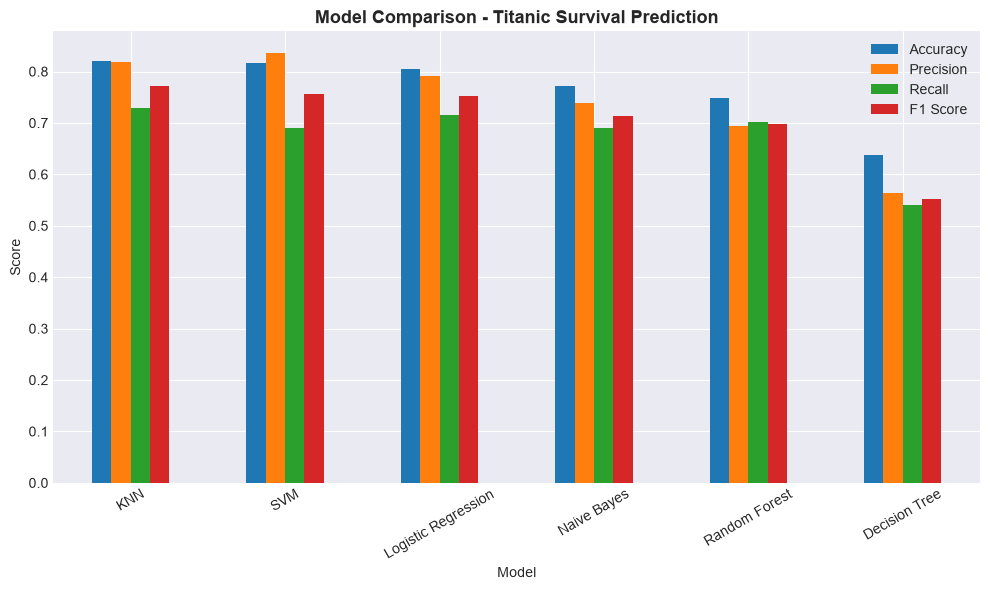

In [26]:
results_df.plot(x='Model', y=['Accuracy','Precision','Recall','F1 Score'],
                 kind='bar', figsize=(10,6))
plt.title('Model Comparison - Titanic Survival Prediction', fontsize = 13 , fontweight = 'bold')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../01-titanic-multi-model-comparison/images/model_comparison.png', dpi = 300)
plt.show()


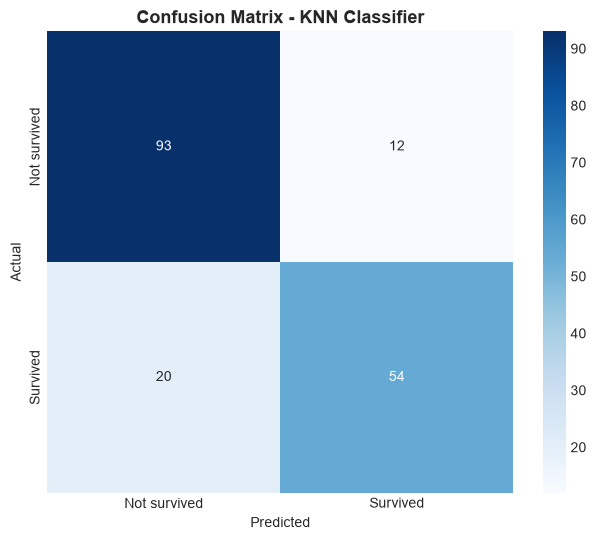

In [30]:
from sklearn.metrics import confusion_matrix

best_model = KNeighborsClassifier()
best_model.fit(X_scaled_train, Y_train)

Y_prediction = best_model.predict(X_scaled_test)

cm = confusion_matrix(Y_test , Y_prediction)

plt.figure(figsize=(6.5,5.5))
sns.heatmap(cm, annot = True, fmt = 'd' , cmap = 'Blues',
            xticklabels= ['Not survived', 'Survived'],
            yticklabels = ['Not survived', 'Survived']
            )
plt.title('Confusion Matrix - KNN Classifier', fontsize = 13 , fontweight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('../01-titanic-multi-model-comparison/images/confusion_matrix.png', dpi=200)
plt.show()

In [33]:

import joblib

joblib.dump(best_model, '../01-titanic-multi-model-comparison/model_knn.pkl')
joblib.dump(scalar, '../01-titanic-multi-model-comparison/scaler.pkl')

['../01-titanic-multi-model-comparison/scaler.pkl']